# modelagem de classificação multiclasse

## classificação de faixa de preço de celulares

nesta etapa, o objetivo é treinar modelos de machine learning para prever a faixa de preço de celulares com base em suas especificações técnicas

a análise exploratória mostrou alguns sinais importantes para a modelagem: `ram` apareceu como uma das variáveis mais relacionadas à faixa de preço, enquanto bateria e resolução de tela também indicaram potencial para diferenciar as classes. ao mesmo tempo, algumas variáveis binárias pareceram ter menor poder de separação quando observadas isoladamente.

como a variável alvo possui quatro categorias, este é um problema de classificação multiclasse:

- `0 = Baixo`
- `1 = Médio`
- `2 = Alto`
- `3 = Muito Alto`

a proposta deste notebook é comparar modelos simples, analisar se variáveis derivadas ajudam no desempenho e selecionar um modelo base consistente para gerar predições no conjunto de teste

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from matplotlib.colors import LinearSegmentedColormap

from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


dark_palette = [
    "#4B000F", 
    "#7A001F",
    "#A83246",
    "#C45A6A",
    "#2B2D42",
    "#1F1F2E",
    "#8D99AE",
    "#D8DEE9"
]

sns.set_theme(
    style="whitegrid",
    palette=dark_palette,
    font_scale=1.05
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

cor = LinearSegmentedColormap.from_list(
    "cor",
    ["#2B2D42", "#8D99AE", "#F4F1EE", "#C45A6A", "#7A001F"],
    N=256
)

class_labels = {
    0: "Baixo",
    1: "Médio",
    2: "Alto",
    3: "Muito Alto"
}

target_names = [class_labels[idx] for idx in sorted(class_labels.keys())]

## carregamento dos dados

conjunto de treino, que será usado na comparação entre os modelos e entre os dois conjuntos de features


In [2]:
df = pd.read_csv("../data/train.csv")

display(df.head())
print(f"Dimensões do dataset de treino: {df.shape[0]} linhas e {df.shape[1]} colunas")

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Dimensões do dataset de treino: 2000 linhas e 21 colunas


## variáveis derivadas para modelagem

a partir dos padrões observados na análise exploratória, foram criadas algumas variáveis derivadas para testar se combinações simples de atributos podem contribuir para o desempenho dos modelos

- `screen_area`: área física aproximada da tela, calculada a partir da altura e largura da tela;
- `pixel_area`: quantidade aproximada de pixels da resolução, calculada a partir da altura e largura em pixels;
- `camera_total`: soma da resolução da câmera frontal com a câmera principal;
- `connectivity_score`: quantidade de recursos de conectividade presentes no aparelho, considerando Bluetooth, dual SIM, 3G, 4G e Wi-Fi.

além da comparação entre variáveis originais e variáveis originais somadas às derivadas, também será testado um terceiro cenário com apenas as variáveis derivadas. a ideia é verificar se essas novas features realmente carregam sinal próprio e se o empilhamento com as originais pode estar aumentando o risco de overfitting

In [3]:
def add_engineered_features(dataframe):
    dataframe = dataframe.copy()
    dataframe["screen_area"] = dataframe["sc_h"] * dataframe["sc_w"]
    dataframe["pixel_area"] = dataframe["px_height"] * dataframe["px_width"]
    dataframe["camera_total"] = dataframe["fc"] + dataframe["pc"]
    dataframe["connectivity_score"] = dataframe[["blue", "dual_sim", "four_g", "three_g", "wifi"]].sum(axis=1)
    return dataframe

derived_features = ["screen_area", "pixel_area", "camera_total", "connectivity_score"]

df_model = add_engineered_features(df)
display(df_model[derived_features].head())

,screen_area,pixel_area,camera_total,connectivity_score
0,63,15120,3,1
1,51,1799140,6,4
2,22,2167308,8,4
3,128,2171776,9,2
4,16,1464096,27,3


## checagem de correlação das variáveis derivadas

antes de ampliar os experimentos, vale repetir no notebook de modelagem a leitura das correlações das variáveis derivadas com a target. isso ajuda a interpretar se um eventual ganho de performance vem de sinal novo ou apenas de redundância em relação às features originais

,correlacao_com_price_range,correlacao_absoluta
pixel_area,0.176240,0.176240
screen_area,0.041248,0.041248
connectivity_score,0.038329,0.038329
camera_total,0.031621,0.031621


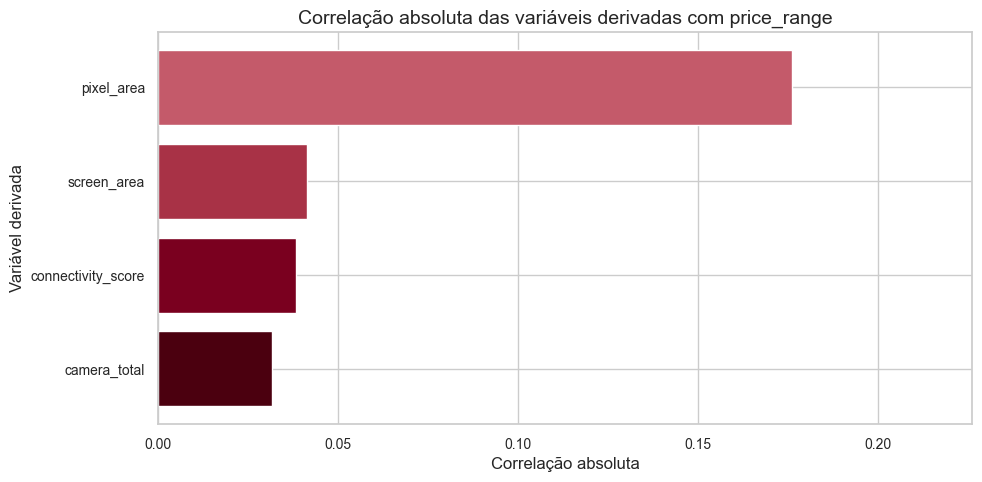

In [4]:
derived_target_corr = (
    df_model[derived_features + ["price_range"]]
    .corr(numeric_only=True)["price_range"]
    .drop("price_range")
    .sort_values(ascending=False)
)

derived_target_corr_df = derived_target_corr.to_frame(name="correlacao_com_price_range")
derived_target_corr_df["correlacao_absoluta"] = derived_target_corr_df["correlacao_com_price_range"].abs()

display(derived_target_corr_df)

plot_data = derived_target_corr.abs().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
colors = [dark_palette[i % len(dark_palette)] for i in range(len(plot_data))]
plt.barh(plot_data.index, plot_data.values, color=colors)
plt.title("Correlação absoluta das variáveis derivadas com price_range")
plt.xlabel("Correlação absoluta")
plt.ylabel("Variável derivada")
plt.xlim(0, plot_data.max() + 0.05)
plt.tight_layout()
plt.show()

essa checagem reforça que `pixel_area` é a derivada com maior sinal individual. as demais contribuem pouco isoladamente, o que torna importante testar um cenário com apenas derivadas antes de concluir que elas ajudam a modelagem

## separação entre features e target

nesta etapa, separamos a variável alvo e montamos três conjuntos de features para comparação:

- `Experimento 1`: variáveis originais
- `Experimento 2`: variáveis originais mais as variáveis derivadas
- `Experimento 3`: somente variáveis derivadas

In [5]:
target = "price_range"

X_original = df.drop(target, axis=1)
y = df[target]

X_engineered = df_model.drop(target, axis=1)
X_derived_only = df_model[derived_features].copy()

all_feature_sets = {
    "Experimento 1: variáveis originais": X_original,
    "Experimento 2: variáveis originais + derivadas": X_engineered,
    "Experimento 3: somente variáveis derivadas": X_derived_only
}

print(f"Formato de X_original: {X_original.shape}")
print(f"Formato de X_engineered: {X_engineered.shape}")
print(f"Formato de X_derived_only: {X_derived_only.shape}")
print(f"Formato de y: {y.shape}")

Formato de X_original: (2000, 20)
Formato de X_engineered: (2000, 24)
Formato de X_derived_only: (2000, 4)
Formato de y: (2000,)


## observação sobre valores zero

nesta primeira versão da modelagem, os valores zero identificados durante a EDA serão mantidos. a ideia é construir um modelo base sem aplicar tratamentos agressivos nos dados. em uma próxima etapa, seria possível testar estratégias específicas para variáveis em que o zero possa indicar inconsistência ou ausência de informação

## divisão entre treino e teste

para garantir uma comparação justa entre os experimentos, vamos usar a mesma divisão treino/teste para os dois conjuntos de features. Assim, a diferença de desempenho tende a refletir mais o efeito das features do que mudanças na amostra de avaliação

In [6]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_original_train = X_original.loc[train_idx]
X_original_test = X_original.loc[test_idx]
X_engineered_train = X_engineered.loc[train_idx]
X_engineered_test = X_engineered.loc[test_idx]
X_derived_only_train = X_derived_only.loc[train_idx]
X_derived_only_test = X_derived_only.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

split_summary = pd.DataFrame({
    "Base completa (%)": y.value_counts(normalize=True).sort_index().mul(100).round(2).rename(index=class_labels),
    "Treino (%)": y_train.value_counts(normalize=True).sort_index().mul(100).round(2).rename(index=class_labels),
    "Teste (%)": y_test.value_counts(normalize=True).sort_index().mul(100).round(2).rename(index=class_labels)
}).reindex(target_names)

display(split_summary)
print(f"X_original_train: {X_original_train.shape} | X_original_test: {X_original_test.shape}")
print(f"X_engineered_train: {X_engineered_train.shape} | X_engineered_test: {X_engineered_test.shape}")
print(f"X_derived_only_train: {X_derived_only_train.shape} | X_derived_only_test: {X_derived_only_test.shape}")

,Base completa (%),Treino (%),Teste (%)
price_range,,,
Baixo,25.0,25.0,25.0
Médio,25.0,25.0,25.0
Alto,25.0,25.0,25.0
Muito Alto,25.0,25.0,25.0


X_original_train: (1600, 20) | X_original_test: (400, 20)
X_engineered_train: (1600, 24) | X_engineered_test: (400, 24)
X_derived_only_train: (1600, 4) | X_derived_only_test: (400, 4)


## modelos de classificação

vamos comparar quatro algoritmos clássicos de classificação multiclasse:

- `Logistic Regression`
- `Decision Tree`
- `Random Forest`
- `KNN`

os modelos mais sensíveis à escala, como Regressão Logística e KNN, serão treinados dentro de um `Pipeline` com `StandardScaler`

In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ])
}

experiment_feature_sets = {
    "Experimento 1: variáveis originais": {
        "X_train": X_original_train,
        "X_test": X_original_test,
        "feature_columns": X_original.columns.tolist()
    },
    "Experimento 2: variáveis originais + derivadas": {
        "X_train": X_engineered_train,
        "X_test": X_engineered_test,
        "feature_columns": X_engineered.columns.tolist()
    },
    "Experimento 3: somente variáveis derivadas": {
        "X_train": X_derived_only_train,
        "X_test": X_derived_only_test,
        "feature_columns": derived_features
    }
}

model_artifacts = {}

## função de avaliação

para evitar repetição de código, vamos criar uma função que treina e avalia os modelos em cada experimento. ela também guarda os modelos treinados, predições e relatórios para análise posterior

In [8]:
def evaluate_models(experiment_name, X_train, X_test, y_train, y_test, models):
    experiment_results = []

    for model_name, model in models.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train)
        y_pred_train = fitted_model.predict(X_train)
        y_pred = fitted_model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average="macro")
        weighted_f1 = f1_score(y_test, y_pred, average="weighted")
        train_accuracy = accuracy_score(y_train, y_pred_train)
        train_macro_f1 = f1_score(y_train, y_pred_train, average="macro")
        train_weighted_f1 = f1_score(y_train, y_pred_train, average="weighted")

        model_artifacts[(experiment_name, model_name)] = {
            "model": fitted_model,
            "predictions": y_pred,
            "classification_report_dict": classification_report(
                y_test,
                y_pred,
                target_names=target_names,
                output_dict=True
            ),
            "classification_report_text": classification_report(
                y_test,
                y_pred,
                target_names=target_names
            ),
            "confusion_matrix": confusion_matrix(y_test, y_pred),
            "feature_columns": X_train.columns.tolist(),
            "X_test": X_test,
            "y_test": y_test
        }

        experiment_results.append({
            "Experimento": experiment_name,
            "Modelo": model_name,
            "Acurácia": accuracy,
            "Macro F1": macro_f1,
            "Weighted F1": weighted_f1,
            "Acurácia treino": train_accuracy,
            "Macro F1 treino": train_macro_f1,
            "Weighted F1 treino": train_weighted_f1,
            "Gap Acurácia": train_accuracy - accuracy,
            "Gap Weighted F1": train_weighted_f1 - weighted_f1
        })

    return pd.DataFrame(experiment_results)

## treinamento e comparação dos experimentos

agora vamos rodar os modelos nos dois conjuntos de features e consolidar os resultados em uma tabela única para comparação

In [9]:
results_frames = []

for experiment_name, feature_set in experiment_feature_sets.items():
    result_df = evaluate_models(
        experiment_name=experiment_name,
        X_train=feature_set["X_train"],
        X_test=feature_set["X_test"],
        y_train=y_train,
        y_test=y_test,
        models=models
    )
    results_frames.append(result_df)

results_df = (
    pd.concat(results_frames, ignore_index=True)
    .sort_values(by=["Weighted F1", "Acurácia"], ascending=False)
    .reset_index(drop=True)
)

results_df

,Experimento,Modelo,Acurácia,Macro F1,Weighted F1,Acurácia treino,Macro F1 treino,Weighted F1 treino,Gap Acurácia,Gap Weighted F1
0,Experimento 1: variáveis originais,Logistic Regression,0.9650,0.964986,0.964986,0.976875,0.976791,0.976791,0.011875,0.011805
1,Experimento 2: variáveis originais + derivadas,Logistic Regression,0.9625,0.962459,0.962459,0.977500,0.977433,0.977433,0.015000,0.014974
2,Experimento 2: variáveis originais + derivadas,Random Forest,0.8925,0.891527,0.891527,1.000000,1.000000,1.000000,0.107500,0.108473
3,Experimento 1: variáveis originais,Random Forest,0.8850,0.885160,0.885160,1.000000,1.000000,1.000000,0.115000,0.114840
4,Experimento 2: variáveis originais + derivadas,Decision Tree,0.8600,0.860073,0.860073,1.000000,1.000000,1.000000,0.140000,0.139927
5,Experimento 1: variáveis originais,Decision Tree,0.8300,0.830168,0.830168,1.000000,1.000000,1.000000,0.170000,0.169832
6,Experimento 1: variáveis originais,KNN,0.5175,0.519914,0.519914,0.690625,0.691157,0.691157,0.173125,0.171243
7,Experimento 2: variáveis originais + derivadas,KNN,0.5150,0.517211,0.517211,0.685625,0.685674,0.685674,0.170625,0.168463
8,Experimento 3: somente variáveis derivadas,Logistic Regression,0.3225,0.264917,0.264917,0.307500,0.261218,0.261218,-0.015000,-0.003700
9,Experimento 3: somente variáveis derivadas,Decision Tree,0.2325,0.231867,0.231867,1.000000,1.000000,1.000000,0.767500,0.768133


## comparação dos resultados

a tabela e o gráfico abaixo ajudam a comparar o desempenho dos modelos entre os três experimentos. aqui, usamos principalmente acurácia e F1-score, com destaque para o `weighted F1`, que resume melhor o desempenho global da classificação

,Experimento,Modelo,Acurácia,Macro F1,Weighted F1,Acurácia treino,Macro F1 treino,Weighted F1 treino,Gap Acurácia,Gap Weighted F1
0,Experimento 1: variáveis originais,Logistic Regression,0.9650,0.9650,0.9650,0.9769,0.9768,0.9768,0.0119,0.0118
1,Experimento 2: variáveis originais + derivadas,Logistic Regression,0.9625,0.9625,0.9625,0.9775,0.9774,0.9774,0.0150,0.0150
2,Experimento 2: variáveis originais + derivadas,Random Forest,0.8925,0.8915,0.8915,1.0000,1.0000,1.0000,0.1075,0.1085
3,Experimento 1: variáveis originais,Random Forest,0.8850,0.8852,0.8852,1.0000,1.0000,1.0000,0.1150,0.1148
4,Experimento 2: variáveis originais + derivadas,Decision Tree,0.8600,0.8601,0.8601,1.0000,1.0000,1.0000,0.1400,0.1399
5,Experimento 1: variáveis originais,Decision Tree,0.8300,0.8302,0.8302,1.0000,1.0000,1.0000,0.1700,0.1698
6,Experimento 1: variáveis originais,KNN,0.5175,0.5199,0.5199,0.6906,0.6912,0.6912,0.1731,0.1712
7,Experimento 2: variáveis originais + derivadas,KNN,0.5150,0.5172,0.5172,0.6856,0.6857,0.6857,0.1706,0.1685
8,Experimento 3: somente variáveis derivadas,Logistic Regression,0.3225,0.2649,0.2649,0.3075,0.2612,0.2612,-0.0150,-0.0037
9,Experimento 3: somente variáveis derivadas,Decision Tree,0.2325,0.2319,0.2319,1.0000,1.0000,1.0000,0.7675,0.7681


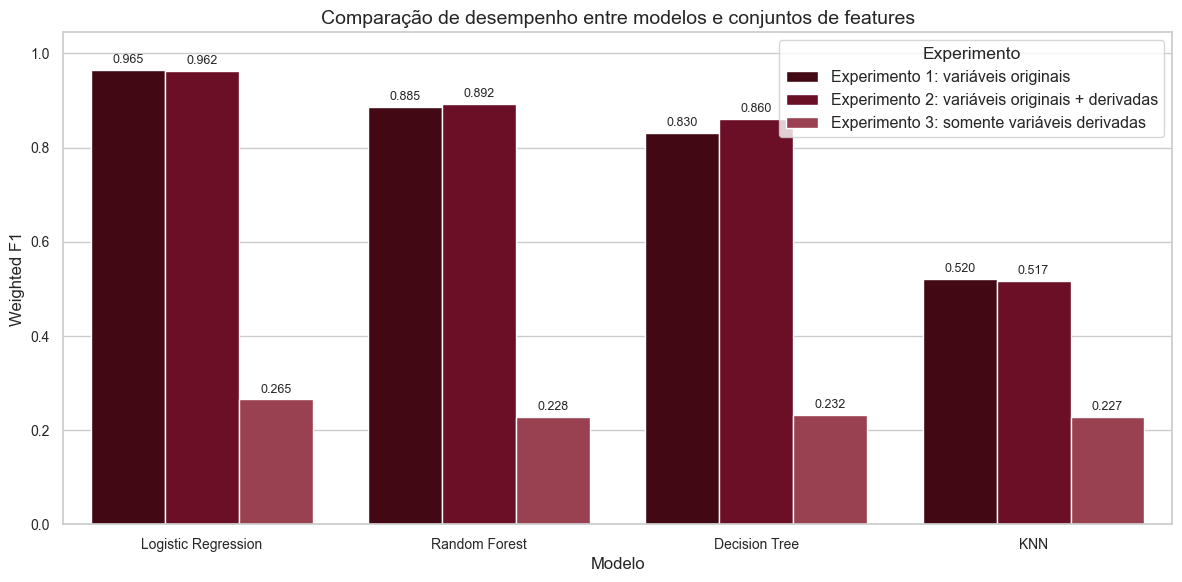

In [10]:
display(results_df.style.format({
    "Acurácia": "{:.4f}",
    "Macro F1": "{:.4f}",
    "Weighted F1": "{:.4f}",
    "Acurácia treino": "{:.4f}",
    "Macro F1 treino": "{:.4f}",
    "Weighted F1 treino": "{:.4f}",
    "Gap Acurácia": "{:.4f}",
    "Gap Weighted F1": "{:.4f}"
}))

plot_df = results_df.copy()
experiment_palette = dark_palette[:plot_df["Experimento"].nunique()]

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=plot_df,
    x="Modelo",
    y="Weighted F1",
    hue="Experimento",
    palette=experiment_palette
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)

ax.set_title("Comparação de desempenho entre modelos e conjuntos de features")
ax.set_xlabel("Modelo")
ax.set_ylabel("Weighted F1")
ax.set_ylim(0, min(1.05, plot_df["Weighted F1"].max() + 0.08))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

os resultados devem ser lidos como um retrato desta divisão treino/teste. além do desempenho em teste, os gaps entre treino e teste adicionados na tabela ajudam a investigar sinais de overfitting. em uma análise mais robusta, seria importante complementar a comparação com validação cruzada e, em uma etapa futura, também com ajuste de hiperparâmetros

## investigação de overfitting

como a hipótese aqui é que o conjunto com variáveis derivadas somadas às originais pode estar inflando a complexidade sem ganho real, vale olhar explicitamente para o gap entre treino e teste

In [18]:
generalization_summary = (
    results_df[[
        "Experimento",
        "Modelo",
        "Acurácia treino",
        "Acurácia",
        "Gap Acurácia",
        "Weighted F1 treino",
        "Weighted F1",
        "Gap Weighted F1"
    ]]
    .sort_values(by="Gap Weighted F1", ascending=False)
    .reset_index(drop=True)
)

display(generalization_summary.style.format({
    "Acurácia treino": "{:.4f}",
    "Acurácia": "{:.4f}",
    "Gap Acurácia": "{:.4f}",
    "Weighted F1 treino": "{:.4f}",
    "Weighted F1": "{:.4f}",
    "Gap Weighted F1": "{:.4f}"
}))

logistic_summary = generalization_summary[generalization_summary["Modelo"] == "Logistic Regression"].copy()
best_logistic = logistic_summary.sort_values(by="Weighted F1", ascending=False).iloc[0]
largest_gap = generalization_summary.iloc[0]
derived_only_logistic = logistic_summary[
    logistic_summary["Experimento"] == "Experimento 3: somente variáveis derivadas"
].iloc[0]

,Experimento,Modelo,Acurácia treino,Acurácia,Gap Acurácia,Weighted F1 treino,Weighted F1,Gap Weighted F1
0,Experimento 3: somente variáveis derivadas,Random Forest,1.0000,0.2275,0.7725,1.0000,0.2278,0.7722
1,Experimento 3: somente variáveis derivadas,Decision Tree,1.0000,0.2325,0.7675,1.0000,0.2319,0.7681
2,Experimento 3: somente variáveis derivadas,KNN,0.4500,0.2300,0.2200,0.4391,0.2273,0.2118
3,Experimento 1: variáveis originais,KNN,0.6906,0.5175,0.1731,0.6912,0.5199,0.1712
4,Experimento 1: variáveis originais,Decision Tree,1.0000,0.8300,0.1700,1.0000,0.8302,0.1698
5,Experimento 2: variáveis originais + derivadas,KNN,0.6856,0.5150,0.1706,0.6857,0.5172,0.1685
6,Experimento 2: variáveis originais + derivadas,Decision Tree,1.0000,0.8600,0.1400,1.0000,0.8601,0.1399
7,Experimento 1: variáveis originais,Random Forest,1.0000,0.8850,0.1150,1.0000,0.8852,0.1148
8,Experimento 2: variáveis originais + derivadas,Random Forest,1.0000,0.8925,0.1075,1.0000,0.8915,0.1085
9,Experimento 2: variáveis originais + derivadas,Logistic Regression,0.9775,0.9625,0.0150,0.9774,0.9625,0.0150


### leitura dos sinais de generalização
nos modelos lineares, o melhor equilíbrio continuou com experimento 1: variáveis originais, que combinou weighted F1 de 0.9650 com gap de 0.0118

o maior sinal de overfitting apareceu em Random Forest no experimento 3: somente variáveis derivadas, com gap de weighted F1 de 0.7722 entre treino e teste

quando o modelo usa apenas variáveis derivadas, a Regressão Logística cai para weighted F1 de 0.2649, o que sugere perda forte de informação ao remover as variáveis originais

## escolha do melhor modelo

a seleção será feita com base no melhor `weighted F1`, usando a acurácia como apoio. isso ajuda a considerar não apenas o total de acertos, mas também o equilíbrio do desempenho entre as classes

In [24]:
best_result = results_df.iloc[0]
best_experiment = best_result["Experimento"]
best_model_name = best_result["Modelo"]
best_model = model_artifacts[(best_experiment, best_model_name)]["model"]
best_predictions = model_artifacts[(best_experiment, best_model_name)]["predictions"]
best_y_test = model_artifacts[(best_experiment, best_model_name)]["y_test"]
best_X_test = model_artifacts[(best_experiment, best_model_name)]["X_test"]
best_feature_columns = model_artifacts[(best_experiment, best_model_name)]["feature_columns"]

print(f"Melhor modelo: {best_model_name} no {best_experiment}")
print(f"Acurácia: {best_result['Acurácia']:.4f}")
print(f"Weighted F1: {best_result['Weighted F1']:.4f}")
print("\nRelatório de classificação:")
print(model_artifacts[(best_experiment, best_model_name)]["classification_report_text"])

Melhor modelo: Logistic Regression no Experimento 1: variáveis originais
Acurácia: 0.9650
Weighted F1: 0.9650

Relatório de classificação:
              precision    recall  f1-score   support

       Baixo       0.99      0.98      0.98       100
       Médio       0.96      0.96      0.96       100
        Alto       0.95      0.94      0.94       100
  Muito Alto       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



### melhor combinação nesta comparação
o melhor resultado foi obtido por Logistic Regression no experimento 1: variáveis originais.

acurácia: 0.9650 <br>
macro F1: 0.9650 <br>
weighted F1: 0.9650

## classification report do melhor modelo

agora vamos detalhar o desempenho do melhor modelo, observando precisão, recall e F1-score em cada classe

In [13]:
best_report_dict = model_artifacts[(best_experiment, best_model_name)]["classification_report_dict"]
best_report_df = pd.DataFrame(best_report_dict).T

display(best_report_df.round(4))
print(model_artifacts[(best_experiment, best_model_name)]["classification_report_text"])

,precision,recall,f1-score,support
Baixo,0.9899,0.980,0.9849,100.000
Médio,0.9600,0.960,0.9600,100.000
Alto,0.9495,0.940,0.9447,100.000
Muito Alto,0.9608,0.980,0.9703,100.000
accuracy,0.9650,0.965,0.9650,0.965
macro avg,0.9650,0.965,0.9650,400.000
weighted avg,0.9650,0.965,0.9650,400.000


              precision    recall  f1-score   support

       Baixo       0.99      0.98      0.98       100
       Médio       0.96      0.96      0.96       100
        Alto       0.95      0.94      0.94       100
  Muito Alto       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



## matriz de confusão do melhor modelo

a matriz de confusão mostra como o modelo distribuiu suas previsões entre as quatro classes. o ideal é concentrar os valores na diagonal principal, que representa os acertos

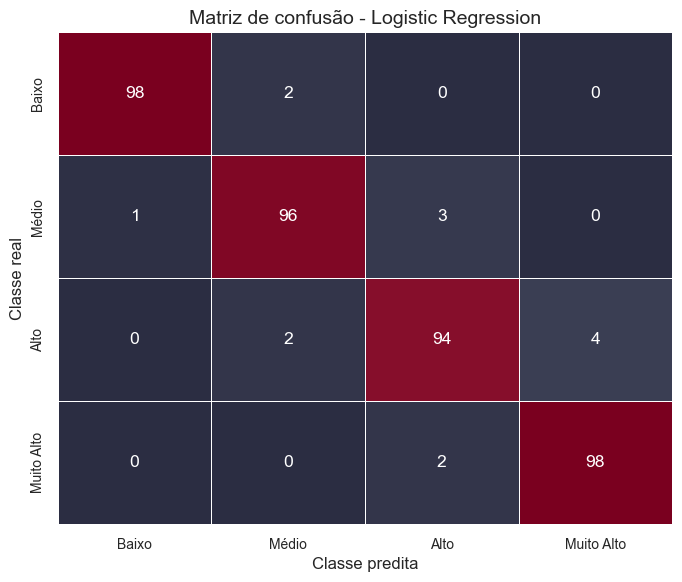

In [14]:
best_cm = model_artifacts[(best_experiment, best_model_name)]["confusion_matrix"]

plt.figure(figsize=(7, 6))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap=cor,
    cbar=False,
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.5
)
plt.title(f"Matriz de confusão - {best_model_name}")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

a maior parte dos acertos está concentrada na diagonal principal, o que indica bom desempenho geral do modelo

a confusão mais frequente ocorreu entre Alto e Muito Alto, com 4 casos. esse tipo de erro costuma acontecer entre classes vizinhas, em que as especificações podem ser mais parecidas

entre as quatro classes, a menor taxa de recall apareceu em Alto (0.940), o que sugere que essa classe merece atenção extra em versões futuras da modelagem

## feature importance

a análise de importância das variáveis ajuda a verificar se os fatores mais relevantes para o modelo estão alinhados com o que apareceu durante a EDA

como o melhor modelo foi uma regressão logística, que não possui `feature_importances_` no mesmo formato dos modelos baseados em árvore, foi utilizado um `Random Forest` como apoio interpretativo para observar a importância das variáveis no mesmo conjunto de features do melhor experimento

,feature,importance
13,ram,0.482643
0,battery_power,0.074376
12,px_width,0.057668
11,px_height,0.055692
8,mobile_wt,0.038386
6,int_memory,0.035831
16,talk_time,0.029860
10,pc,0.029631
15,sc_w,0.028088
2,clock_speed,0.027332


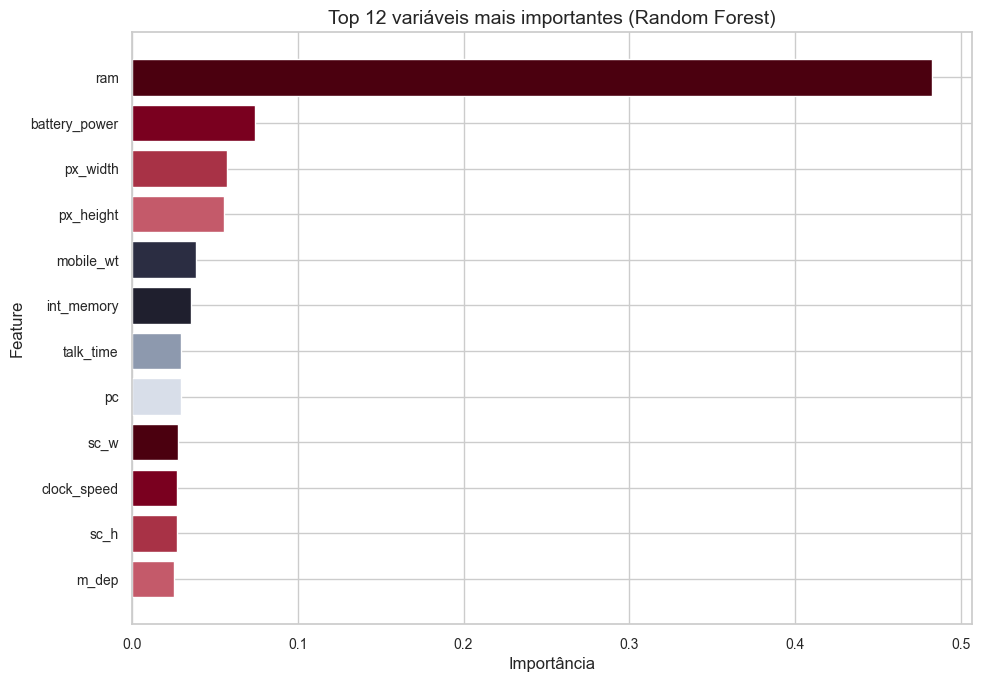

In [15]:
if hasattr(best_model, "named_steps"):
    candidate_estimator = best_model.named_steps["model"]
else:
    candidate_estimator = best_model

if hasattr(candidate_estimator, "feature_importances_"):
    importance_model_name = best_model_name
    importance_model = candidate_estimator
else:
    importance_model_name = "Random Forest"
    importance_model = model_artifacts[(best_experiment, "Random Forest")]["model"]

importance_df = pd.DataFrame({
    "feature": best_feature_columns,
    "importance": importance_model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(importance_df.head(12))

plt.figure(figsize=(10, 7))
top_importance = importance_df.head(12).copy()
bar_colors = [dark_palette[i % len(dark_palette)] for i in range(len(top_importance))]
ax = plt.barh(top_importance["feature"], top_importance["importance"], color=bar_colors)
plt.title(f"Top 12 variáveis mais importantes ({importance_model_name})")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

como o melhor modelo foi uma Regressão Logística, esta leitura de importância foi feita com Random Forest apenas como apoio interpretativo

as variáveis mais relevantes nessa análise foram `ram`, `battery_power`, `px_width`, `px_height`, `mobile_wt`

a variável ram apareceu na posição 1 do ranking de importância. isso está alinhado com a EDA, que já indicava a RAM como um dos sinais mais fortes para separar as faixas de preço. bateria, resolução de tela, peso e memória interna também aparecem como variáveis úteis nessa leitura interpretativa, o que reforça a coerência entre exploração e modelagem

## validação cruzada simples

além da avaliação em uma única divisão treino/teste, vamos aplicar validação cruzada no melhor modelo usando o melhor conjunto de features. isso ajuda a verificar se o desempenho se mantém razoavelmente consistente em diferentes partições dos dados

In [16]:
X_best = all_feature_sets[best_experiment]
best_model_for_cv = clone(models[best_model_name])

cv_scores = cross_val_score(best_model_for_cv, X_best, y, cv=5, scoring="accuracy")
cv_summary = pd.DataFrame({
    "score": cv_scores
})

display(cv_summary)
print(f"Média da acurácia na validação cruzada: {cv_scores.mean():.4f}")
print(f"Desvio padrão da acurácia: {cv_scores.std():.4f}")
print(f"Scores individuais: {np.round(cv_scores, 4)}")

,score
0,0.9600
1,0.9575
2,0.9675
3,0.9650
4,0.9675


Média da acurácia na validação cruzada: 0.9635
Desvio padrão da acurácia: 0.0041
Scores individuais: [0.96   0.9575 0.9675 0.965  0.9675]


## predição no arquivo `test.csv`

agora vamos aplicar o melhor modelo ao conjunto `test.csv`. as mesmas transformações de feature engineering serão reproduzidas quando o melhor experimento usar variáveis derivadas, inclusive no cenário com apenas derivadas

In [17]:
test_df = pd.read_csv("../data/test.csv")
test_df_model = add_engineered_features(test_df)

test_feature_sets = {
    "Experimento 1: variáveis originais": test_df.drop(columns=["id"], errors="ignore"),
    "Experimento 2: variáveis originais + derivadas": test_df_model.drop(columns=["id"], errors="ignore"),
    "Experimento 3: somente variáveis derivadas": test_df_model[derived_features].copy()
}

test_features = test_feature_sets[best_experiment].reindex(columns=X_best.columns)

final_model = clone(models[best_model_name])
final_model.fit(X_best, y)

test_predictions = final_model.predict(test_features)
test_prediction_labels = pd.Series(test_predictions).map(class_labels)

if "id" in test_df.columns:
    submission_df = pd.DataFrame({
        "id": test_df["id"],
        "predicted_price_range": test_predictions,
        "predicted_price_label": test_prediction_labels
    })
else:
    submission_df = pd.DataFrame({
        "predicted_price_range": test_predictions,
        "predicted_price_label": test_prediction_labels
    })

submission_df.to_csv("../data/mobile_price_predictions.csv", index=False)

display(submission_df.head())
print("Arquivo salvo em: ../data/mobile_price_predictions.csv")

,id,predicted_price_range,predicted_price_label
0,1,3,Muito Alto
1,2,3,Muito Alto
2,3,2,Alto
3,4,3,Muito Alto
4,5,1,Médio


Arquivo salvo em: ../data/mobile_price_predictions.csv


## conclusão

neste notebook, foram comparados quatro modelos de classificação multiclasse: Logistic Regression, Decision Tree, Random Forest e KNN. a avaliação considerou três cenários: um com as variáveis originais, outro com as variáveis originais acrescidas das variáveis derivadas e um terceiro com apenas as variáveis derivadas construídas a partir dos insights do EDA.

a melhor combinação continuou sendo Logistic Regression no Experimento 1: variáveis originais, com acurácia de 0.9650, macro F1 de 0.9650 e weighted F1 de 0.9650. isso indica que, nesta base, as variáveis originais já oferecem sinal suficiente para separar bem as faixas de preço.

a suspeita de overfitting ganhou suporte parcial com a leitura dos gaps treino-teste: na Regressão Logística, o experimento com variáveis originais manteve desempenho ligeiramente melhor e gap menor do que a versão com originais + derivadas. nos modelos baseados em árvore, os gaps ficaram bem maiores, especialmente quando o conjunto foi reduzido apenas às variáveis derivadas.

o terceiro experimento também ajudou a qualificar o papel das novas features. quando usadas sozinhas, as variáveis derivadas perderam desempenho de forma acentuada, o que sugere que elas não substituem o conteúdo informacional das colunas originais. na prática, `pixel_area` parece captar algum sinal útil, mas `screen_area`, `camera_total` e `connectivity_score` são insuficientes para sustentar uma boa classificação isoladamente.

a validação cruzada do melhor modelo indicou desempenho consistente em diferentes divisões dos dados, o que fortalece a confiança nesse modelo base. na etapa de interpretabilidade, como a Regressão Logística não fornece `feature_importances_` no mesmo formato de modelos baseados em árvore, foi usado um Random Forest como apoio interpretativo, reforçando especialmente o papel de `ram` e, em menor grau, de bateria, resolução de tela, peso e memória interna.